In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp

In [2]:
# Wind speed and angle
v = 10
phi = np.pi/4

In [3]:
# Building drift, change in drift, and the ode to solve
def w(x, y):
    return np.column_stack((5*y, np.zeros_like(y))).T

def dw(x, y):
    return np.array([
        [0, 5],
        [0, 0]
    ])

def ode(t, Y, p):
    v = 10
    T = p[0]
    x, y, l1, l2 = Y
    lnorm = np.sqrt(l1**2 + l2**2) + 1e-10

    u1 = v * l1 / lnorm
    u2 = v * l2 / lnorm

    w1, w2 = w(x, y)
  
    dx = T * (u1 + w1)
    dy = T * (u2 + w2)

    Dw = dw(x, y)
    dl1, dl2 = -T * (Dw.T @ np.array([l1, l2]))

    return np.array([dx, dy, dl1, dl2])
    
x0 = np.array([0, 0])
xf = np.array([4, 4])

def bc(ya, yb, p):
    T = p[0]
    v=10

    xa, ya, l1a, l2a = ya
    xb, yb, l1b, l2b = yb

    lam_norm = np.sqrt(l1b**2 + l2b**2) + 1e-10
    u1b = v * l1b / lam_norm
    u2b = v * l2b / lam_norm
    wb = w(xb, yb).squeeze(1)
    
    Hf = l1b * (u1b + wb[0]) + l2b * (u2b + wb[1]) - 1.0

    return np.array([
        xa - x0[0],
        ya - x0[1],
        xb - xf[0],
        yb - xf[1],
        Hf
    ])


t = np.linspace(0, 1, 100)

# initial guess
Y_guess = np.zeros((4, t.size))
Y_guess[0] = np.linspace(x0[0], xf[0], t.size)
Y_guess[1] = np.linspace(x0[1], xf[1], t.size)
Y_guess[2] = 1.0
Y_guess[3] = 1.0

p_guess = np.array([2.0])

sol = solve_bvp(ode, bc, t, Y_guess, p=p_guess)

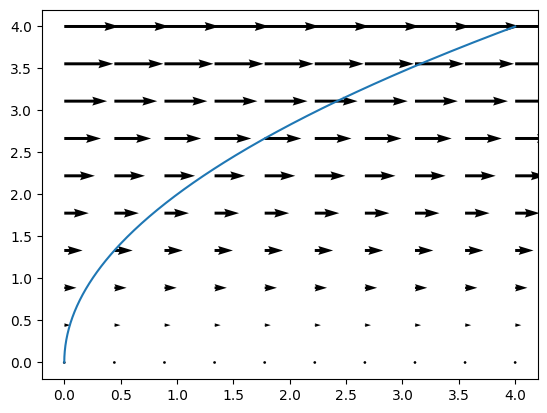

In [4]:
plt.plot(sol.y[0], sol.y[1])

x = np.linspace(0, 4, 10)

X, Y = np.meshgrid(x, x)

U = 5 * Y
V = np.zeros_like(X)

plt.quiver(X, Y, U, V)

plt.show()